
# กำลังรันการอนุมาน StormCast

พื้นฐาน StormCast inference workflow

ตัวอย่างนี้จะสาธิตวิธีการรัน inference workflow อย่างง่ายเพื่อสร้าง
deterministic forecast เบื้องต้นโดยใช้ StormCast สำหรับรายละเอียดเกี่ยวกับโมเดล Stormcast
ดู

- https://arxiv.org/abs/2408.10958


In [ ]:
# /// script
# dependencies = [
#   "earth2studio[data,stormcast] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การเตรียมองค์ประกอบ
workflow ทุกตัวภายใน Earth2Studio จำเป็นต้องได้รับคอมโพเนนต์ที่สร้างไว้ล่วงหน้าแล้วส่งเข้าไปให้ใช้งาน ในตัวอย่างนี้เราจะดูเวิร์กโฟลว์พื้นฐานที่สุดคือ
:py:meth:`earth2studio.run.deterministic`.



.. literalinclude:: ../../earth2studio/run.py
   :language: python
   :start-after: # sphinx - deterministic start
   :end-before: # sphinx - deterministic end



ดังนั้น เราจึงต้องมีองค์ประกอบต่อไปนี้:

- Prognostic Model: ใช้ StormCast รุ่น :py:class:`earth2studio.models.px.StormCast` ในตัว
- Datasource: ดึงข้อมูลจาก HRRR data API ผ่าน :py:class:`earth2studio.data.HRRR`.
- IO Backend: บันทึกผลลัพธ์ลงใน Zarr store ผ่าน :py:class:`earth2studio.io.ZarrBackend`.

StormCast ยังต้องการแหล่งข้อมูลการปรับสภาพด้วย เราใช้แหล่งข้อมูล forecast ที่นี่
GFS_FX :py:class:`earth2studio.data.GFS_FX` ซึ่งเป็นค่าเริ่มต้น แต่ไม่ใช่ forecast
แหล่งข้อมูลเช่น ARCO สามารถใช้กับการประทับเวลาที่เหมาะสมได้



In [1]:
from datetime import datetime, timedelta

from loguru import logger
from tqdm import tqdm

logger.remove()
logger.add(lambda msg: tqdm.write(msg, end=""), colorize=True)

import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from earth2studio.data import HRRR
from earth2studio.io import ZarrBackend
from earth2studio.models.px import StormCast

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
# ใช้แหล่งข้อมูลการปรับสภาพดีฟอลต์ GFS_FX
package = StormCast.load_default_package()
model = StormCast.load_model(package)

# สร้างแหล่งข้อมูล
data = HRRR()

# สร้างตัวจัดการ IO เก็บไว้ในหน่วยความจำ
io = ZarrBackend()

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


## การรัน Workflow
เมื่อคอมโพเนนต์ทั้งหมดเริ่มต้นแล้ว การรัน workflow จะเป็นโค้ด Python บรรทัดเดียว
เวิร์กโฟลว์จะส่งคืนอ็อบเจ็กต์ IO ที่ระบุกลับไปยังผู้ใช้ ซึ่งสามารถนำมาใช้ได้
จากนั้นจึงโพสต์กระบวนการ บางตัวมี API เพิ่มเติมซึ่งมีประโยชน์สำหรับ post-processing หรือ
บันทึกเป็นไฟล์ ตรวจสอบเอกสาร API สำหรับข้อมูลเพิ่มเติม

สำหรับการพยากรณ์ เราจะคาดการณ์เป็นเวลา 4 ชั่วโมง



In [2]:
import earth2studio.run as run

nsteps = 4
today = datetime.today() - timedelta(days=1)
date = today.isoformat().split("T")[0]
io = run.deterministic([date], nsteps, model, data, io)

print(io.root.tree())

2026-04-24 15:31:54.552 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-24 15:31:54.552 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching HRRR data:   0%|          | 0/99 [00:00<?, ?it/s]

2026-04-24 15:31:56.487 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20260423/conus/hrrr.t00z.wrfnatf00.grib2 66472029-2197067
2026-04-24 15:31:56.489 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20260423/conus/hrrr.t00z.wrfnatf00.grib2 360691996-643519
2026-04-24 15:31:56.492 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20260423/conus/hrrr.t00z.wrfnatf00.grib2 80121268-2194742
2026-04-24 15:31:56.494 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20260423/conus/hrrr.t00z.wrfnatf00.grib2 7456447-1399627
2026-04-24 15:31:56.496 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20260423/conus/hrrr.t00z.wrfnatf00.grib2 93997778-2190085
2026-04-24 15:31:56.497 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fet

Fetching HRRR data: 100%|██████████| 99/99 [00:11<00:00,  8.39it/s]


2026-04-24 15:32:08.433 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from HRRR
2026-04-24 15:32:08.521 | INFO     | earth2studio.run:deterministic:139 - Inference starting!


...

2026-04-24 15:33:12.255 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f002 346717104-946946
2026-04-24 15:33:12.264 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f002 207539883-738792
2026-04-24 15:33:12.269 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f002 0-1042844
2026-04-24 15:33:12.272 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f002 401438710-966135
2026-04-24 15:33:12.275 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f002 402404845-956334
2026-04-24 15:33:12.278 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib fi

Fetching GFS data: 100%|██████████| 26/26 [00:04<00:00,  6.36it/s]
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xe80a7c8c5a90>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xe80a7cc44d10>, 2070241.20987272), (<aiohttp.client_proto.ResponseHandler object at 0xe80a7cc45550>, 2070241.224955157), (<aiohttp.client_proto.ResponseHandler object at 0xe80a7cc45370>, 2070241.306077806), (<aiohttp.client_proto.ResponseHandler object at 0xe80a7cc46f90>, 2070241.324513786), (<aiohttp.client_proto.ResponseHandler object at 0xe80a7cc45730>, 2070241.528436837), (<aiohttp.client_proto.ResponseHandler object at 0xe80a7c8d02f0>, 2070241.794112917), (<aiohttp.client_proto.ResponseHandler object at 0xe80a7cc45130>, 2070241.809416185), (<aiohttp.client_proto.ResponseHandler object at 0xe80a7cc44b30>, 2070241.830426526), (<aiohttp.client_proto.ResponseHandler object at 0xe80a7cc44ef0>, 2070241.9050206

2026-04-24 15:33:44.422 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f003 398401924-1224323
2026-04-24 15:33:44.427 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f003 338989577-903175
2026-04-24 15:33:44.430 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f003 342078860-1364065
2026-04-24 15:33:44.432 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f003 207583138-735318
2026-04-24 15:33:44.435 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f003 268734596-931610
2026-04-24 15:33:44.438 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GF

Running inference: 100%|██████████| 5/5 [02:08<00:00, 25.78s/it]

2026-04-24 15:34:17.432 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── Z10hl (1, 5, 512, 640) float32
├── Z11hl (1, 5, 512, 640) float32
├── Z13hl (1, 5, 512, 640) float32
├── Z15hl (1, 5, 512, 640) float32
├── Z1hl (1, 5, 512, 640) float32
├── Z20hl (1, 5, 512, 640) float32
├── Z25hl (1, 5, 512, 640) float32
├── Z2hl (1, 5, 512, 640) float32
├── Z30hl (1, 5, 512, 640) float32
├── Z3hl (1, 5, 512, 640) float32
├── Z4hl (1, 5, 512, 640) float32
├── Z5hl (1, 5, 512, 640) float32
├── Z6hl (1, 5, 512, 640) float32
├── Z7hl (1, 5, 512, 640) float32
├── Z8hl (1, 5, 512, 640) float32
├── Z9hl (1, 5, 512, 640) float32
├── hrrr_x (640,) float64
├── hrrr_y (512,) float64
├── lead_time (5,) timedelta64[h]
├── mslp (1, 5, 512, 640) float32
├── p10hl (1, 5, 512, 640) float32
├── p11hl (1, 5, 512, 640) float32
├── p13hl (1, 5, 512, 640) float32
├── p15hl (1, 5, 512, 640) float32
├── p1hl (1, 5, 512, 640) float32
├── p20hl (1, 5, 512, 640) float32
├── p2hl (1, 5, 512, 640

## การทำ Post-Processing
ขั้นตอนสุดท้ายคือการนำผลลัพธ์มาทำ post-process ต่อ Cartopy เป็นไลบรารีที่ยอดเยี่ยมสำหรับการพล็อต
ฟิลด์ข้อมูลบน projection ของทรงกลม ตรงนี้เราจะพลอตอุณหภูมิที่ 2 เมตร
(t2m) ใน forecast เป็นเวลา 4 ชั่วโมง

สังเกตว่าฟังก์ชัน Zarr IO มี API เพิ่มเติมสำหรับใช้เข้าถึงและจัดการข้อมูลที่เก็บไว้



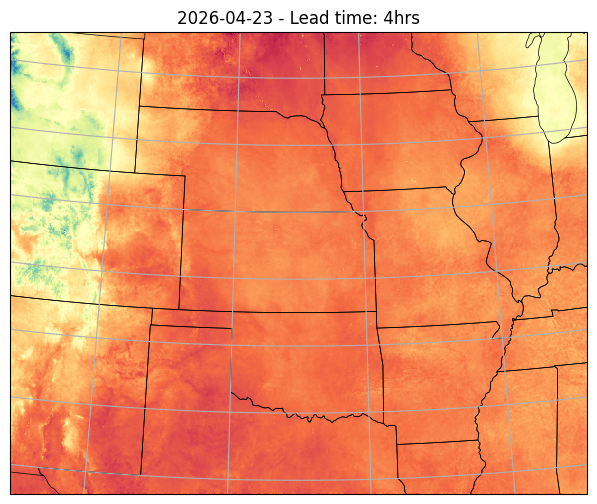

In [3]:
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

forecast = f"{date}"
variable = "t2m"
step = 4  # lead time = 1 ชม

plt.close("all")

# สร้าง Lambert Conformal projection ที่ถูกต้อง
projection = ccrs.LambertConformal(
    central_longitude=262.5,
    central_latitude=38.5,
    standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)

# สร้างรูปและแกนด้วย projection ที่ระบุ
fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))

# พล็อตฟิลด์โดยใช้ pcolormesh
im = ax.pcolormesh(
    model.lon,
    model.lat,
    io[variable][0, step],
    transform=ccrs.PlateCarree(),
    cmap="Spectral_r",
)

# กำหนดเส้นสถานะ
ax.add_feature(
    cartopy.feature.STATES.with_scale("50m"), linewidth=0.5, edgecolor="black", zorder=2
)

# ตั้งชื่อเรื่อง
ax.set_title(f"{forecast} - Lead time: {step}hrs")

# เพิ่มแนวชายฝั่งและเส้นกริด
ax.coastlines()
ax.gridlines()
plt.savefig(f"outputs/09_{date}_t2m_prediction.jpg")